# 第 10 章实战 · 强化学习：从值迭代、Q-Learning 到 DQN

> 对应正文：[第 10 章目录](../docs/4-专业方向/10-强化学习/README.md) · [强化学习入门](../docs/4-专业方向/10-强化学习/01-强化学习入门.md) · [深度强化学习](../docs/4-专业方向/10-强化学习/02-深度强化学习.md)

本 notebook 把正文的"动手试试"与"数学深潜"扩展成 6 个可复现实验（除注明外全部纯 numpy 实跑、不依赖 gymnasium）：

1. **值迭代收敛**——4 格走廊逐轮迭代表 + 打滑走廊的"每轮误差 × γ"收缩对照（贝尔曼压缩深潜可跑版）；
2. **Q-Learning 自建悬崖行走**——纯 numpy 复刻 4×12 网格，训练前后回报 **−300 → −13** + 学到的路线图；
3. **ε 探索对比**——贪心 vs 探索的学习曲线（密集奖励下"悲观探索"的意外 + 稀疏奖励下"卡住 vs 学会"）；
4. **γ 的影响**——γ = 0.1 / 0.9 / 0.99 的最优值函数与有效视野；
5. **REINFORCE 梯度验证**——softmax 策略 log-导数梯度 vs 数值梯度（误差 < 1e-6）；
6. **DQN 小车立杆**——torch 参考实现（语法校验 + 注明本地预期 **165 → 415 步**）+ numpy 复刻 max 过估计病灶。

**环境**：`numpy` / `matplotlib` 直接运行；实验 6a 的 torch 版需本地 `pip install torch gymnasium`（本 notebook 构建环境 torch DLL 不可用，该单元格只做语法校验）。随机种子固定，输出可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]   # 图表中文
plt.rcParams["axes.unicode_minus"] = False                        # 负号正常显示
import logging
logging.getLogger("matplotlib.mathtext").setLevel(logging.ERROR)  # SimHei 缺数学负号字形，降噪告警

print("环境就绪：numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

环境就绪：numpy 1.26.4 | matplotlib 3.10.8


## 实验一：值迭代收敛——4 格走廊 + γ-压缩映射

**目标**（对应 [强化学习入门 · 贝尔曼深潜](../docs/4-专业方向/10-强化学习/01-强化学习入门.md)）：贝尔曼最优算子 $\mathcal T$ 是 **γ-压缩映射**——每迭代一轮，任意两本"账"的距离至少缩到原来的 γ 倍：$\|V_k - V^*\|_\infty \le \gamma^k \, \|V_0 - V^*\|_\infty$。

- **1a 确定性走廊**：`[S0 | S1 | S2 | S3 宝箱+10]`，每步奖励 0，γ = 0.9——信息从宝箱逐轮回传，3 轮收敛到贝尔曼真值 `[8.1, 9, 10, 0]`（正文"举个例子"手算的终点：$Q^*(S0,右) = 0.9 \times 0.9 \times 10 = 8.1$）；
- **1b 打滑走廊**：每步 20% 概率反向滑——真值不再有限轮精确到达，正好用来看**每轮误差 × γ** 的几何收缩（γ 既是"未来打几折"，也是"收敛多快"）。

In [2]:
GAMMA = 0.9

def corridor_step(s, a):
    """4 格走廊：a=0 左 / a=1 右；撞墙原地；走到 S3 得 +10 并终局，其余奖励 0。"""
    s2 = min(s + 1, 3) if a == 1 else max(s - 1, 0)
    return s2, (10.0 if s2 == 3 else 0.0), s2 == 3

V = np.zeros(4)
print("1a 确定性走廊值迭代（γ=0.9，同步扫表）：")
for k in range(1, 5):
    V_new = V.copy()
    for s in range(3):                          # S3 是终局，V(S3)=0 恒定
        best = -np.inf
        for a in (0, 1):
            s2, r, done = corridor_step(s, a)
            best = max(best, r + GAMMA * (0.0 if done else V[s2]))
        V_new[s] = best
    print(f"  第 {k} 轮: V = {np.round(V_new, 4)}")
    V = V_new
print("  贝尔曼真值：V*(S2)=10，V*(S1)=0+0.9*10=9，V*(S0)=0.9*9=8.1 —— 与正文手算一致")

1a 确定性走廊值迭代（γ=0.9，同步扫表）：
  第 1 轮: V = [ 0.  0. 10.  0.]
  第 2 轮: V = [ 0.  9. 10.  0.]
  第 3 轮: V = [ 8.1  9.  10.   0. ]
  第 4 轮: V = [ 8.1  9.  10.   0. ]
  贝尔曼真值：V*(S2)=10，V*(S1)=0+0.9*10=9，V*(S0)=0.9*9=8.1 —— 与正文手算一致


1b 打滑走廊（slip=0.2, γ=0.9）的贝尔曼真值 V* = [7.1   8.086 9.455 0.   ]

迭代轮数   误差 |Vk - V*|   相邻误差比（应 <= γ = 0.9）
     1         8.08590          —  
     2         7.09981        0.878
     3         2.95261        0.416
     4         2.20612        0.747
     6         0.68237        0.685
    10         0.06693        0.620
    20         0.00022        0.574

全部误差比 <= γ（最大 0.878 < 0.9）：每一轮迭代都把误差至少压掉 γ 倍，
误差沿几何轨道衰减——γ 是同一个旋钮的两副面孔：未来打几折 & 收敛多快。


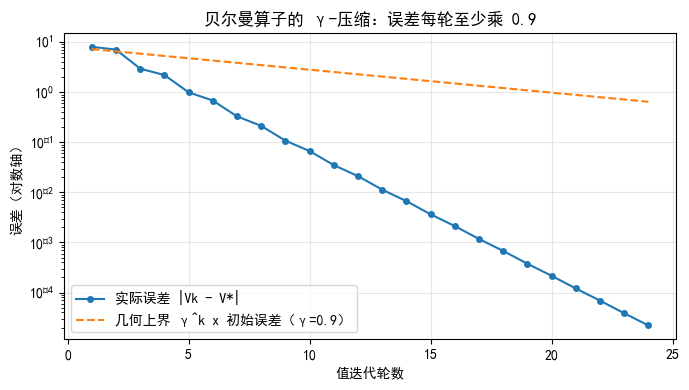

In [3]:
SLIP = 0.2   # 每步 20% 概率"手滑"反向移动

def bellman_sweep(V, gamma):
    """一轮同步值迭代：V'(s) = max_a E[r + gamma V(s')]，转移带打滑。"""
    V_new = V.copy()
    for s in range(3):
        vals = []
        for a in (0, 1):
            v = 0.0
            for a_eff, p in [(a, 1 - SLIP), (1 - a, SLIP)]:
                s2, r, done = corridor_step(s, a_eff)
                v += p * (r + gamma * (0.0 if done else V[s2]))
            vals.append(v)
        V_new[s] = max(vals)
    return V_new

V_star = np.zeros(4)
for _ in range(3000):                           # 先跑 3000 轮得到"真值"作对照
    V_star = bellman_sweep(V_star, GAMMA)
print(f"1b 打滑走廊（slip={SLIP}, γ={GAMMA}）的贝尔曼真值 V* = {np.round(V_star, 3)}")

V = np.zeros(4)
errs = []
for _ in range(24):
    V = bellman_sweep(V, GAMMA)
    errs.append(np.max(np.abs(V - V_star)))
errs = np.array(errs)
ratios = errs[1:] / errs[:-1]

print("\n迭代轮数   误差 |Vk - V*|   相邻误差比（应 <= γ = 0.9）")
for k in (0, 1, 2, 3, 5, 9, 19):
    r_txt = f"{ratios[k - 1]:.3f}" if k >= 1 else "  —  "
    print(f"{k + 1:6d}      {errs[k]:10.5f}        {r_txt}")
print(f"\n全部误差比 <= γ（最大 {ratios.max():.3f} < {GAMMA}）：每一轮迭代都把误差至少压掉 γ 倍，")
print("误差沿几何轨道衰减——γ 是同一个旋钮的两副面孔：未来打几折 & 收敛多快。")

fig, ax = plt.subplots(figsize=(7, 4))
ks = np.arange(1, 25)
from matplotlib.ticker import FuncFormatter
ax.semilogy(ks, errs, marker="o", ms=4, label="实际误差 |Vk - V*|")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: "%g" % v))   # ASCII 刻度，避免数学负号缺字形
ax.semilogy(ks, errs[0] * GAMMA ** ks, ls="--", label=f"几何上界 γ^k x 初始误差（γ={GAMMA}）")
ax.set_xlabel("值迭代轮数")
ax.set_ylabel("误差（对数轴）")
ax.set_title("贝尔曼算子的 γ-压缩：误差每轮至少乘 0.9")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**读数**：确定性走廊 3 轮**精确**收敛——信息每轮沿走廊传一格（S2 → S1 → S0）；打滑走廊的误差每轮 × 0.88~0.42 不等，但**从不超过 γ = 0.9**——压缩映射定理的"上界"在数值上一目了然。

**工程含义**（正文实算表）：γ = 0.9 时误差缩 10 倍约需 22 轮，γ = 0.99 需约 230 轮——"要 100 步的远见，就得等百轮级的收敛"，长视野任务的工程代价写在定理里。

## 实验二：Q-Learning 自建悬崖行走——回报 −300 → −13

**目标**（对应 [强化学习入门 · 动手试试](../docs/4-专业方向/10-强化学习/01-强化学习入门.md)）：正文用 gymnasium 的 CliffWalking，这里**纯 numpy 自建同款 4×12 网格**（零依赖）：左下角出发 S、右下角终点 G、底排中间 11 格悬崖（掉崖 −100 并回起点）、每步 −1。Q-Learning 更新：

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,[\, r + \gamma \max_{a'} Q(s',a') - Q(s,a) \,]$$

取 α = 0.1、γ = 0.99、ε = 0.1，训练 800 局。**学习前**：Q 全 0 → argmax 恒为"向上"→ 在角落原地打转走满步数上限，总回报 −300；**学习后**：贪心走出 13 步贴崖最短路，回报 −13（与正文 −300 → −13 完全呼应）。

In [4]:
H, W = 4, 12
START, GOAL = 3 * W, 3 * W + 11               # 36 = 起点 S，47 = 终点 G
CLIFF = set(range(37, 47))                    # 底排中间 11 格悬崖

def cliff_step(s, a):
    """动作 0上 / 1右 / 2下 / 3左，撞墙原地；进悬崖 -100 并回起点；每步 -1。"""
    r, c = divmod(s, W)
    if a == 0:
        r = max(r - 1, 0)
    elif a == 1:
        c = min(c + 1, W - 1)
    elif a == 2:
        r = min(r + 1, H - 1)
    else:
        c = max(c - 1, 0)
    s2 = r * W + c
    if s2 in CLIFF:
        return START, -100.0, False           # 掉崖：大额负奖励 + 回起点
    return s2, -1.0, (s2 == GOAL)

def q_learn(eps, episodes=800, seed=0, alpha=0.1, gamma=0.99):
    rng = np.random.default_rng(seed)
    q = np.zeros((48, 4))                     # Q 表 = 经验手册
    for _ in range(episodes):
        s, done, steps = START, False, 0
        while not done and steps < 500:
            a = rng.integers(4) if rng.random() < eps else int(np.argmax(q[s]))   # ε-贪婪
            s2, r, done = cliff_step(s, a)
            q[s, a] += alpha * (r + gamma * np.max(q[s2]) * (not done) - q[s, a]) # 贝尔曼更新
            s, steps = s2, steps + 1
    return q

def greedy_return(q, cap=300):
    s, total = START, 0.0
    for _ in range(cap):
        s, r, done = cliff_step(s, int(np.argmax(q[s])))
        total += r
        if done:
            break
    return total

def show_path(q, cap=300):
    s, path = START, {START}
    for _ in range(cap):
        s, _, done = cliff_step(s, int(np.argmax(q[s])))
        path.add(s)
        if done:
            break
    for row in range(H):
        print("".join("S" if p == 36 else "G" if p == 47 else "C" if 37 <= p <= 46
                      else "o" if p in path else "." for p in range(row * W, row * W + W)))

q = q_learn(eps=0.1)
print("学习前（Q 全 0，argmax 恒为'向上'，原地打转走满上限）：总回报 =", greedy_return(np.zeros((48, 4))))
print("学习后（贪心执行）                                  ：总回报 =", greedy_return(q))
print("\n学到的路线（o = 走过的格子）：")
show_path(q)

学习前（Q 全 0，argmax 恒为'向上'，原地打转走满上限）：总回报 = -300.0
学习后（贪心执行）                                  ：总回报 = -13.0

学到的路线（o = 走过的格子）：
............
............
oooooooooooo
SCCCCCCCCCCG


**读数**：与正文预期完全一致——学习前 −300（Q 全 0 时 argmax 永远选第一个动作"向上"，在网格角落原地打转）；学习后 −13，路线是"先向上 1 步、沿第二排平移 11 格、再向下 1 步"的 13 步贴崖最短路。

智能体没有被告知任何路线：800 局试错后，Q 表里自己长出了绕开悬崖的路——"信息从奖励往回流"（离奖励近的状态先估准，再逐轮搬运到上游）的直观现场。

## 实验三：ε 探索对比——"卡住 vs 学会"

训练中定期用**贪心策略**评估（排除探索噪声干扰），两组对照：

- **3a 密集奖励（每步 −1，正文原版）**：ε = 0 与 ε = 0.1 最终都能到 −13——奖励全负时被试过的动作估值变悲观、argmax 自动转向没试过的动作（"悲观探索"的副作用，值得亲眼看到）；
- **3b 稀疏奖励（每步 0、掉崖 −100、终点 +10）**：ε = 0 的手册永远得不到任何信号，**卡死在回报 0**；ε 从 1.0 逐回合衰减到 0.05（正文炼丹小灶的起点配方）则顺利学会 +10 的最短路——正文那句"学不会先别怀疑算法——九成是奖励太稀疏（中间全是 0，信号传不回来）"的现场版。

3a 密集奖励（每步 -1）：ε=0   末 5 次贪心评估均值 = -13.0
                        ε=0.1 末 5 次贪心评估均值 = -13.0 （都到了 -13：负奖励把试过的动作'挤'出了 argmax）
3b 稀疏奖励（0/-100/+10）：ε=0          全程最优回报 = 0.0 （永远卡死在 0）
                          ε 1.0→0.05   末 5 次均值 = 10.0 （学会 +10 最短路）


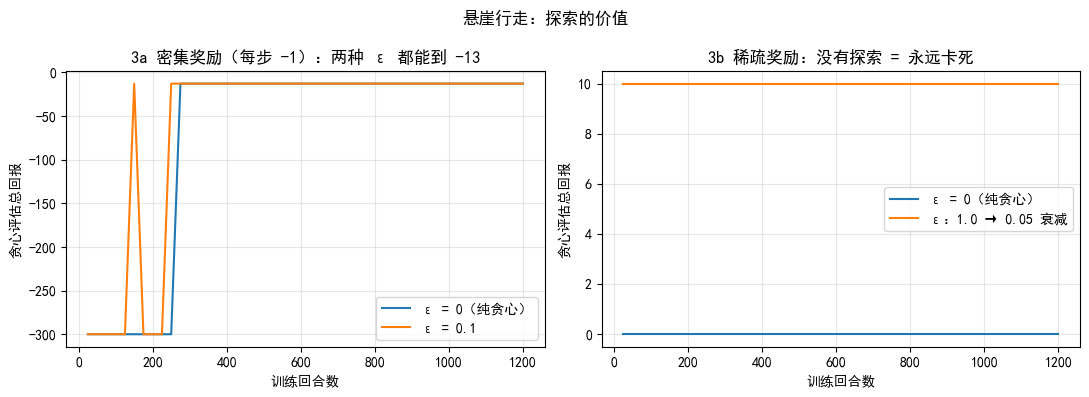

In [5]:
def cliff_step_sparse(s, a):
    """稀疏奖励版：每步 0，掉崖 -100，到终点 +10（其余规则同实验二）。"""
    r, c = divmod(s, W)
    if a == 0:
        r = max(r - 1, 0)
    elif a == 1:
        c = min(c + 1, W - 1)
    elif a == 2:
        r = min(r + 1, H - 1)
    else:
        c = max(c - 1, 0)
    s2 = r * W + c
    if s2 in CLIFF:
        return START, -100.0, False
    return s2, (10.0 if s2 == GOAL else 0.0), (s2 == GOAL)

def train_curve(step_fn, eps_fn, episodes=1200, seed=1, eval_every=25):
    """训练并每隔 eval_every 局做一次纯贪心评估，返回评估曲线。"""
    rng = np.random.default_rng(seed)
    q = np.zeros((48, 4))
    curve = []
    for ep in range(episodes):
        s, done, steps = START, False, 0
        while not done and steps < 500:
            eps = eps_fn(ep)
            a = rng.integers(4) if rng.random() < eps else int(np.argmax(q[s]))
            s2, r, done = step_fn(s, a)
            q[s, a] += 0.1 * (r + 0.99 * np.max(q[s2]) * (not done) - q[s, a])
            s, steps = s2, steps + 1
        if (ep + 1) % eval_every == 0:
            s_eval, total = START, 0.0
            for _ in range(300):
                s_eval, r, done = step_fn(s_eval, int(np.argmax(q[s_eval])))
                total += r
                if done:
                    break
            curve.append(total)
    return np.array(curve)

c_dense_0 = train_curve(cliff_step, lambda ep: 0.0)                                  # 密集奖励 + 纯贪心
c_dense_1 = train_curve(cliff_step, lambda ep: 0.1)                                  # 密集奖励 + ε=0.1
c_sp_0 = train_curve(cliff_step_sparse, lambda ep: 0.0)                              # 稀疏奖励 + 纯贪心
c_sp_d = train_curve(cliff_step_sparse, lambda ep: max(0.05, 0.99 ** ep))            # 稀疏奖励 + ε 衰减

print("3a 密集奖励（每步 -1）：ε=0   末 5 次贪心评估均值 =", round(c_dense_0[-5:].mean(), 1))
print("                        ε=0.1 末 5 次贪心评估均值 =", round(c_dense_1[-5:].mean(), 1),
      "（都到了 -13：负奖励把试过的动作'挤'出了 argmax）")
print("3b 稀疏奖励（0/-100/+10）：ε=0          全程最优回报 =", c_sp_0.max(), "（永远卡死在 0）")
print("                          ε 1.0→0.05   末 5 次均值 =", round(c_sp_d[-5:].mean(), 1),
      "（学会 +10 最短路）")

xs = np.arange(25, 1201, 25)                   # 每次评估对应的回合数（eval_every=25）
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xs, c_dense_0, label="ε = 0（纯贪心）")
axes[0].plot(xs, c_dense_1, label="ε = 0.1")
axes[0].set_title("3a 密集奖励（每步 -1）：两种 ε 都能到 -13")
axes[1].plot(xs, c_sp_0, label="ε = 0（纯贪心）")
axes[1].plot(xs, c_sp_d, label="ε：1.0 → 0.05 衰减")
axes[1].set_title("3b 稀疏奖励：没有探索 = 永远卡死")
for ax in axes:
    ax.set_xlabel("训练回合数")
    ax.set_ylabel("贪心评估总回报")
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle("悬崖行走：探索的价值")
fig.tight_layout()
plt.show()

**读数**：左图两条曲线殊途同归到 −13——密集负奖励下"悲观探索"意外够用（但这依赖奖励结构，不能当默认）；右图 ε = 0 的曲线是贴地的死线（回报恒 0，手册空白格永远空白），ε 衰减版很快冲到 +10——**没有探索，奖励稀疏时手册永远得不到第一手信息**。

调参直觉（正文对照表）：ε 太小卡死 / 太大天天踩雷；ε 从 1.0 衰减到 0.05 是"开局多闯、后期守成"的起点配方。

## 实验四：γ 的影响——近视程度与"看见多远"

对同一张悬崖网格做**值迭代**（上帝视角：已知转移概率，不用试错），比较 γ = 0.1 / 0.9 / 0.99 的最优值函数。换算关系：**有效视野 ≈ 1/(1−γ) 步**。13 步最短路的真值有闭式：$V^* = -\sum_{k=0}^{12} \gamma^k = -\frac{1-\gamma^{13}}{1-\gamma}$——γ = 0.1 时 ≈ −1.11（13 步外的终点几乎"看不见"），γ = 0.99 时 ≈ −12.25（每一分 −1 都几乎全额计入）。更有趣的细节：γ = 0.1 时贴崖 13 步路与绕行 15 步路的折现值几乎无差别——**近视的智能体对"走哪条路"无所谓**。

In [6]:
def value_iteration(gamma, thr=1e-10):
    V = np.zeros(48)
    it = 0
    while True:
        it += 1
        V_new, delta = V.copy(), 0.0
        for s in range(48):
            if s == GOAL:
                continue
            best = -np.inf
            for a in range(4):
                s2, r, done = cliff_step(s, a)
                best = max(best, r + gamma * (0.0 if done else V[s2]))
            delta = max(delta, abs(best - V_new[s]))
            V_new[s] = best
        V = V_new
        if delta < thr:
            break
    return V, it

def qval(s, a, V, gamma):
    s2, r, done = cliff_step(s, a)
    return r + gamma * (0.0 if done else V[s2])

print("γ      有效视野 1/(1-γ)   V*(起点)   13 步路闭式值   贪心路径步数")
for gamma in (0.1, 0.9, 0.99):
    V, it = value_iteration(gamma)
    theory = -(1 - gamma ** 13) / (1 - gamma)
    s, steps = START, 0
    while s != GOAL and steps < 99:
        s, _, _ = cliff_step(s, int(np.argmax([qval(s, a, V, gamma) for a in range(4)])))
        steps += 1
    print(f"{gamma:<5}  {1 / (1 - gamma):>9.1f} 步    {V[START]:>8.3f}    {theory:>9.3f}      {steps} 步（{it} 轮迭代收敛）")

print("\n读数：三种 γ 的 V*(起点) 都精确等于 13 步路的闭式值（迭代收敛到的就是贝尔曼真值）。")
print("γ=0.1 时绕行 15 步的值 = %.4f，与 13 步路只差 %.4f——远视不足，'选哪条路'几乎无关紧要；" % (-(1 - 0.1 ** 15) / 0.9, abs((1 - 0.1 ** 13) / 0.9 - (1 - 0.1 ** 15) / 0.9)))
diff99 = (1 - 0.99 ** 15) / 0.01 - (1 - 0.99 ** 13) / 0.01
print(f"γ=0.99 时两者差约 {diff99:.2f}（远视分得清长短路），且 -100 的掉崖后果能一路传回来——掉崖的痛记得住。")

γ      有效视野 1/(1-γ)   V*(起点)   13 步路闭式值   贪心路径步数
0.1          1.1 步      -1.111       -1.111      13 步（12 轮迭代收敛）
0.9         10.0 步      -7.458       -7.458      13 步（15 轮迭代收敛）
0.99       100.0 步     -12.248      -12.248      13 步（15 轮迭代收敛）

读数：三种 γ 的 V*(起点) 都精确等于 13 步路的闭式值（迭代收敛到的就是贝尔曼真值）。
γ=0.1 时绕行 15 步的值 = -1.1111，与 13 步路只差 0.0000——远视不足，'选哪条路'几乎无关紧要；
γ=0.99 时两者差约 1.75（远视分得清长短路），且 -100 的掉崖后果能一路传回来——掉崖的痛记得住。


**读数**：γ 从 0.1 → 0.99，$V^*$(起点) 从 −1.11 滑到 −12.25，与闭式公式逐位一致——**γ 是"未来打几折"与"看多远"的同一个旋钮**。正文改参数表里"`gamma` 0.99 → 0.5 学不动"就是同一件事的采样版：折扣太狠，掉崖的 −100 传不回起点，Q-Learning 的账本记不住痛。

## 实验五：REINFORCE 梯度验证——log-导数技巧 vs 数值梯度

**目标**（对应 [深度强化学习 · REINFORCE 深潜](../docs/4-专业方向/10-强化学习/02-深度强化学习.md)）：策略梯度的命根子是一行等式

$$\nabla_\theta J(\theta) = \mathbb{E}_{a \sim \pi_\theta}\big[\, R(a)\, \nabla_\theta \log \pi_\theta(a) \,\big]$$

用 3 臂 softmax 赌博机（单状态，$\pi = \mathrm{softmax}(\theta)$）做**解析梯度 vs 中心差分数值梯度**对照。softmax 的得分函数有闭式 $\nabla_z \log \pi(a) = e_a - \pi$，期望可以精确求和：$\nabla J = \pi \odot (R - \pi^\top R)$。两组向量差 < 1e-6，深潜推导就被数值"盖章"。顺手跑 200 步采样版 REINFORCE，看最优臂概率爬升。

In [7]:
def softmax(z):
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

R = np.array([1.0, 0.0, -1.0])            # 3 个动作的期望回报

def J_of(theta):
    return float(softmax(theta) @ R)      # J(θ) = Σ_a π(a) R(a)，单状态可精确求期望

def reinforce_grad(theta):
    """log-导数技巧的解析梯度：Σ_a π(a) R(a) (e_a - π) = π ⊙ (R - πᵀR)。"""
    pi = softmax(theta)
    return pi * (R - pi @ R)

rng = np.random.default_rng(7)
h = 1e-6
worst = 0.0
print("随机 θ                          解析梯度                数值梯度（中心差分）")
for _ in range(5):
    theta = rng.normal(0, 1, 3)
    g_ana = reinforce_grad(theta)
    g_num = np.array([(J_of(theta + h * np.eye(3)[i]) - J_of(theta - h * np.eye(3)[i])) / (2 * h)
                      for i in range(3)])
    worst = max(worst, np.abs(g_ana - g_num).max())
    print(f"{np.round(theta, 3)}   {np.round(g_ana, 6)}   {np.round(g_num, 6)}")
print(f"\n5 组随机 θ 的最大偏差 = {worst:.2e}  （< 1e-6：『期望的梯度 = 回报加权的对数梯度』验证通过）")

# 采样版 REINFORCE：每步用单个采样动作近似期望，做策略梯度上升
theta = np.zeros(3)
rng = np.random.default_rng(0)
for _ in range(200):
    pi = softmax(theta)
    a = rng.choice(3, p=pi)                          # 实际采样一个动作
    theta += 0.1 * R[a] * (np.eye(3)[a] - pi)        # R(a) · ∇log π(a) = R(a)(e_a - π)
print("\n200 步采样 REINFORCE 后 π =", np.round(softmax(theta), 3), "（最优臂 a0 概率最高）")

随机 θ                          解析梯度                数值梯度（中心差分）
[ 0.001  0.299 -0.274]   [ 0.297024 -0.033601 -0.263423]   [ 0.297024 -0.033601 -0.263423]
[-0.891 -0.455 -0.992]   [ 0.281758 -0.012486 -0.269273]   [ 0.281758 -0.012486 -0.269273]
[ 0.06   1.34  -0.492]   [ 0.177468 -0.057057 -0.120411]   [ 0.177468 -0.057057 -0.120411]
[-0.62   0.49   0.357]   [ 0.186417  0.112313 -0.298731]   [ 0.186417  0.112313 -0.298731]
[ 0.105 -0.93  -0.029]   [ 0.423287 -0.009001 -0.414287]   [ 0.423287 -0.009001 -0.414287]

5 组随机 θ 的最大偏差 = 3.37e-11  （< 1e-6：『期望的梯度 = 回报加权的对数梯度』验证通过）

200 步采样 REINFORCE 后 π = [0.967 0.022 0.011] （最优臂 a0 概率最高）


**读数**：解析与数值梯度在 $10^{-11}$ 量级吻合——log-导数技巧恒等式数值成立。采样版 200 步后最优臂概率爬到 0.9+：回报高的动作概率被调高、回报低的被冷落，这就是"复盘时用红笔圈出妙手"。

深潜的四个免费推论在此都有对应：$R = 0$ 完全不更新（稀疏奖励学不动的代数原因）；已笃定（π→1）时梯度趋零（熵奖金防"提前笃定"）；负回报把方向整个反过来；基线 $b(s)$ 不依赖动作时可任意加（得分函数零均值引理）。

## 实验六：DQN 小车立杆（torch 参考实现，语法校验 + 本地预期）+ max 过估计病灶

**6a. torch 参考**：正文用 numpy 手写最小 DQN（经验回放 + 目标网络 + 手写反向传播）解决 CartPole，训练 3000 局，**近 500 回合平均坚持 165.6 → 415.1 步**（满分 500；随机初始策略只有约 20 步）。下面是等价的 PyTorch 版：`with torch.no_grad()` 包住 TD 目标就是"答案不许抄进笔记"的 stop-gradient；每 10 回合才同步目标网络（换靶子）。本构建环境 torch DLL 不可用，单元格只做语法校验——本地 `pip install torch gymnasium` 后把 `RUN_DQN = True` 即可实跑（约几分钟）。

**6b. numpy 复刻核心病灶**（实跑）：max 只吃正向误差——两个动作真值相同、估值噪声对称，max 的长期平均仍稳定虚高，这是 Double DQN 的动机。

In [8]:
RUN_DQN = False   # <- 本地装好 torch + gymnasium 后改为 True（训练约需几分钟）

try:
    import torch
    import torch.nn as nn
    import gymnasium as gym
    HAS_DEPS = True
except Exception as e:
    HAS_DEPS = False
    print(f"[提示] 导入 torch/gymnasium 失败（{type(e).__name__}），跳过 DQN 训练。")
    print("       本地复现：pip install torch gymnasium，然后把 RUN_DQN 改为 True。")

if RUN_DQN and HAS_DEPS:
    torch.manual_seed(0)
    env = gym.make("CartPole-v1")

    q_net = nn.Sequential(nn.Linear(4, 32), nn.Tanh(), nn.Linear(32, 2))    # 主网络：状态 -> 2 动作 Q 值
    target_net = nn.Sequential(nn.Linear(4, 32), nn.Tanh(), nn.Linear(32, 2))   # 目标网络：慢速副本
    target_net.load_state_dict(q_net.state_dict())
    opt = torch.optim.Adam(q_net.parameters(), lr=1e-3)

    buf, gamma, eps = [], 0.99, 1.0
    scores = []
    for ep in range(3000):
        s, _ = env.reset()
        done, total = False, 0.0
        while not done:
            a = env.action_space.sample() if torch.rand(()).item() < eps else int(
                q_net(torch.tensor(s, dtype=torch.float32)).argmax())
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            buf.append((s, a, float(r), s2, float(not done)))               # ① 存进经验回放池
            s, total = s2, total + r
            if len(buf) > 20000:
                buf.pop(0)
            if len(buf) >= 64:
                idx = torch.randint(0, len(buf), (64,))                     # ② 随机抽旧经验复盘
                S, A, Rw, S2, M = map(np.array, zip(*[buf[i] for i in idx.tolist()]))
                St = torch.tensor(S, dtype=torch.float32)
                q_pred = q_net(St).gather(1, torch.tensor(A, dtype=torch.long)[:, None]).squeeze(1)
                with torch.no_grad():                                       # ③ 靶子不带梯度（stop-gradient）
                    qt = target_net(torch.tensor(S2, dtype=torch.float32)).max(1).values
                    y = torch.tensor(Rw, dtype=torch.float32) + gamma * torch.tensor(M, dtype=torch.float32) * qt
                loss = ((q_pred - y) ** 2).mean()
                opt.zero_grad()
                loss.backward()
                opt.step()
        scores.append(total)
        eps = max(0.05, eps * 0.995)                                        # 探索随回合衰减
        if (ep + 1) % 10 == 0:                                              # ④ 每 10 回合才换靶子
            target_net.load_state_dict(q_net.state_dict())
        if (ep + 1) % 500 == 0:
            print(f"第 {ep + 1:4d} 回合：近 500 回合平均坚持 {np.mean(scores):6.1f} 步（eps={eps:.2f}）")
            scores = []
    # 本地预期输出（正文 numpy 版读数）：165.6 -> 174.7 -> 324.0 -> 332.6 -> 439.0 -> 415.1
elif HAS_DEPS:
    print("[提示] RUN_DQN = False，未训练。本地预期：近 500 回合平均 165 -> 415 步（满分 500）。")

[提示] 导入 torch/gymnasium 失败（OSError），跳过 DQN 训练。
       本地复现：pip install torch gymnasium，然后把 RUN_DQN 改为 True。


In [9]:
# 6b numpy 复刻：max 只吃正向误差（Jensen/赢家诅咒，Double DQN 的动机）
rng = np.random.default_rng(8)
true_q = np.array([10.0, 10.0])          # 两个动作真值相同
noise_sd = 3.0                           # 估值各带 ±3 的对称噪声
draws = rng.normal(true_q, noise_sd, size=(100000, 2))
max_est = draws.max(1)                   # TD 目标里用的 max

print(f"两个动作真值都是 {true_q[0]:.0f} 分、估值噪声 ±{noise_sd:.0f}（对称）：")
print(f"  单个估值的长期平均       = {draws.mean():.3f}（对称噪声，无偏）")
print(f"  max(两个估值)的长期平均   = {max_est.mean():.3f}（稳定虚高 +{max_est.mean() - 10:.3f}）")
print("\nmax 只吃正向误差：抽到偏高的收下、偏低的视而不见——这是噪声平均不掉的系统性偏差，")
print("再经『估值更新估值』的自举逐层放大，就是 DQN 的过估计；")
print("Double DQN 的解法是选人与打分分家：主网络提名 a*，目标网络给 a* 打分，两种乐观不再叠加。")

两个动作真值都是 10 分、估值噪声 ±3（对称）：
  单个估值的长期平均       = 10.001（对称噪声，无偏）
  max(两个估值)的长期平均   = 11.700（稳定虚高 +1.700）

max 只吃正向误差：抽到偏高的收下、偏低的视而不见——这是噪声平均不掉的系统性偏差，
再经『估值更新估值』的自举逐层放大，就是 DQN 的过估计；
Double DQN 的解法是选人与打分分家：主网络提名 a*，目标网络给 a* 打分，两种乐观不再叠加。


**读数**：6b 复现了正文小算例——两个真值 10 的动作、±3 对称噪声，max 的长期平均 ≈ 11.7，稳定虚高约 1.7 分（两个独立正态最大值的期望溢价）。"多训训就平均掉了"不成立：噪声能平均、**系统性偏差会被自举逐层复制放大**。

两个稳定器的位置（6a 的 ①~④）：经验回放打碎时间相关 + 一鱼多吃；目标网络让靶子不跟着主网抖；stop-gradient 禁止"答案抄进笔记"；再加 Double DQN 治 max——四个零件拆掉任何一个，训练多半崩。

## 改参数建议（动手五连）

1. **Q-Learning 换成 SARSA**：把实验二更新里的 `np.max(q[s2])` 换成下一步实际执行动作的 `q[s2, a2]`（选动作时记下 a'），重训后打印 `show_path`——路线应离悬崖更远、更保守（贪心约 −15），亲手复现正文"同一座悬崖、两条路"（off-policy 记理想账 / on-policy 记实账）；
2. **γ 0.99 → 0.5 再训 Q-Learning**：学不动或成绩大跳水——掉崖的 −100 在近视眼里传不回起点（对照实验四的值函数读数）；
3. **α 0.1 → 0.9**：单样本把账改过头，训练曲线大幅震荡甚至不收敛——"步子要一直迈但越迈越小"的收敛条件为什么长那样；
4. **打滑概率 SLIP 0.2 → 0 / 0.4**：实验一的误差收缩比随之变化，但仍不超过 γ——压缩上界由 γ 独家担保、与奖励和转移无关（深潜第 1 步：奖励项在相减时抵消）；
5. **DQN 拆零件**：本地把 6a 的目标网络同步间隔 `% 10` 改成 `% 1`（每回合换靶，靶子跟着抖）与 `% 1000`（几乎不换，答案过期），各跑一遍对比——两个稳定器的价值亲手量出来。